In [6]:
### To find the exact CDR string ###
import subprocess
result = subprocess.run(["wb", "resource", "list"], capture_output=True, text=True)
print(result.stdout)

ID           RESOURCE TYPE  STEWARDSHIP TYPE  DESCRIPTION                 
C2025Q4R6    BQ_DATASET     REFERENCED        (unset)                     
zip3_bucket  GCS_BUCKET     CONTROLLED        stores files for chloropleth



In [11]:
## Get BigQuery project location, run this to find complete reference ###
result = subprocess.run(["wb", "resource", "describe", "--name=C2025Q4R6"], capture_output=True, text=True)
print(result.stdout)

ID:           C2025Q4R6
Description:  
Type:         BQ_DATASET
Stewardship:  REFERENCED
Cloning:      COPY_REFERENCE
Properties:   class Properties {
    []
}
GCP project id:      wb-silky-artichoke-2408
BigQuery dataset id: C2025Q4R6
Location:            us-central1
# Tables:            133



# Obtain ZIP3 information from All of Us participants

In [16]:
# =============================================================================
# 1. QUERY ZIP code observation data from All of Us BigQuery
# =============================================================================
# observation_concept_id 3043579 = ZIP code tabulation area (OMOP)

from google.cloud import bigquery
WORKSPACE_CDR = "wb-silky-artichoke-2408.C2025Q4R6"
client = bigquery.Client()

observation_sql = """
    SELECT
        observation.person_id,
        observation.value_as_number,
        observation.value_as_string
    FROM (
        SELECT *
        FROM `{cdr}.observation`
        WHERE observation_concept_id IN (3043579)
    ) observation
""".format(cdr=WORKSPACE_CDR)

dataset_76442823_observation_df = client.query(observation_sql).to_dataframe()
dataset_76442823_observation_df.shape
dataset_76442823_observation_df.head(5)

,person_id,value_as_number,value_as_string
0,1144938,NaN,545**
1,1029392,NaN,981**
2,1146643,NaN,531**
3,6596351,NaN,863**
4,1983106,NaN,959**


# Clean ZIP3 data and add population density information

In [18]:
# =============================================================================
# 2. PROCESS: Clean and summarize ZIP3 data
# =============================================================================
# Rename dataframe with ZIP3 information (use .copy() to avoid SettingWithCopyWarning)
df = dataset_76442823_observation_df.copy()

# Extract ZIP3 from the start of the string (anchored to avoid partial matches)
df['zip3'] = df['value_as_string'].str.extract(r'^(\d{3})')

# List of ZIP3 prefixes to exclude
exclude_zip3 = [
    # Alaska
#    '995','996','997','998','999', 
    # Hawaii
#    '967','968',
    # Puerto Rico
#    '006','007','009',
    # US Virgin Islands, Guam
    '969', '008',
    # Military
    '090','091','092','093','094','095','096','097','098','099','569',
    # Federal offices
    '202','203','204','205',
    # PO Box ZIP3 codes that have no population data
    '753','772',
    # Drop individuals without zip3 information
    '000'
]

# Filter out excluded ZIP3s and rows where zip3 extraction failed (NaN)
df_clean = df[df['zip3'].notna() & ~df['zip3'].isin(exclude_zip3)].copy()

# Keep only person_id and ZIP3
df_clean = df_clean[['person_id', 'zip3']]

# Count individuals per ZIP3
zip3_counts = df_clean.groupby('zip3').size().reset_index(name='n_individuals')

# Load population data
pop_df = pd.read_csv("zip3_population_density_2014_2023.csv")
pop_df['zip3'] = pop_df['zip3'].astype(str).str.zfill(3)

# Filter for 2020
pop2020 = pop_df[pop_df['year'] == 2020][['zip3', 'population']]

# Merge population into counts (left join keeps all ZIP3s in counts)
zip3_counts = zip3_counts.merge(pop2020, on='zip3', how='left')

# Warn about any ZIP3s with missing population data
missing_pop = zip3_counts[zip3_counts['population'].isna()]
if not missing_pop.empty:
    print(f"WARNING: {len(missing_pop)} ZIP3(s) have no population data and will have NaN prop_percent:")
    print(missing_pop['zip3'].tolist())

# Compute proportion of local population
zip3_counts['prop_percent'] = (zip3_counts['n_individuals'] / zip3_counts['population']) * 100

# =============================================================================
# 3. OUTPUT
# =============================================================================
# Preview
print(zip3_counts.head())

# Save to CSV
zip3_counts.to_csv("dataset_zip3.prop_percent.csv", index=False)

  zip3  n_individuals  population  prop_percent
0  006            788     1064354      0.074036
1  007           2045     1217832      0.167921
2  009           2977      971244      0.306514
3  010            644      475217      0.135517
4  011            123      169408      0.072606


In [23]:
### Determine new proportions in v9 data
print(zip3_counts.nlargest(10, 'prop_percent')[['zip3', 'n_individuals', 'population', 'prop_percent']])

    zip3  n_individuals  population  prop_percent
130  152          19035      675992      2.815862
317  352          12402      498699      2.486871
331  367           2127      101990      2.085499
487  537           6202      299602      2.070080
763  857          17131      919608      1.862859
129  151           6629      364875      1.816787
494  544           6899      386597      1.784546
452  495           7186      430811      1.668017
505  558           1686      116835      1.443061
354  392           3190      225226      1.416355


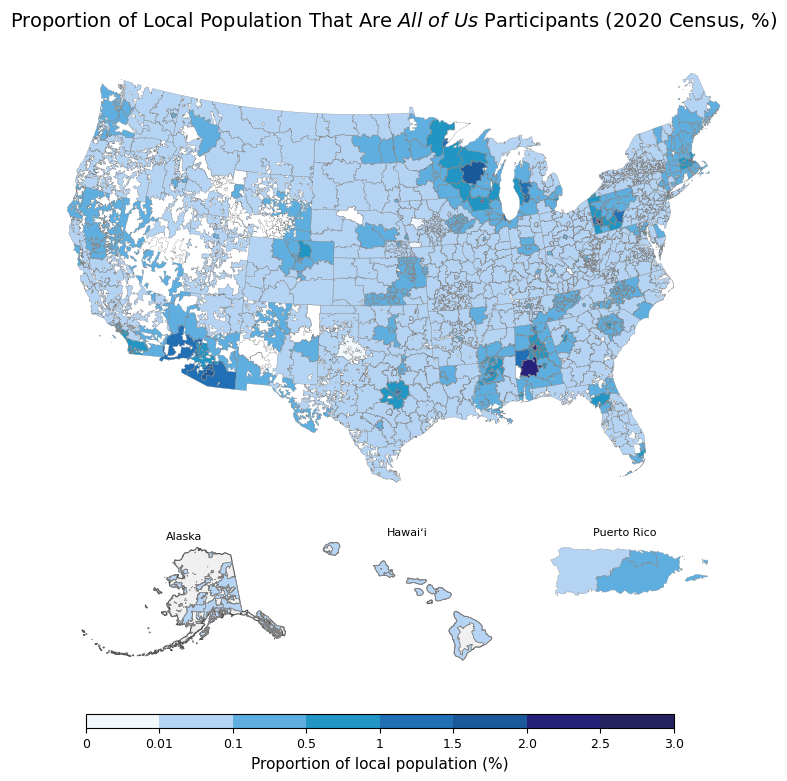

In [53]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import FancyBboxPatch

import os
os.environ["PROJ_LIB"] = "/usr/share/proj"

# ── Load data ─────────────────────────────────────────────────────────────────
zip3_geo = gpd.read_file("zip3_shapes.geojson")   # all geometries, no data yet
zip3_counts = pd.read_csv("dataset_zip3.prop_percent.csv")
zip3_counts['zip3'] = zip3_counts['zip3'].astype(str).str.zfill(3)
zip3_map = zip3_geo.merge(zip3_counts[['zip3','prop_percent']], on='zip3', how='left')
zip3_map = zip3_map.to_crs(epsg=2163)

# Full geometry for every ZIP3 (including those with no participants)
zip3_geo = zip3_geo.to_crs(epsg=2163)

# Load US state boundaries for Alaska background outline
states = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_state_5m.zip"
).to_crs(epsg=3338)
ak_state = states[states["STUSPS"] == "AK"]
hi_state = states[states["STUSPS"] == "HI"].to_crs(epsg=26904)

# Offset zeros so they fall in the lowest bin
zip3_map['prop_plot'] = zip3_map['prop_percent'].copy()
zip3_map.loc[zip3_map['prop_plot'] == 0, 'prop_plot'] = 0.001

# ── Color scheme ──────────────────────────────────────────────────────────────
bounds = [0, 0.01, 0.1, 0.5, 1, 1.5, 2.0, 2.5, 3.0]
# Light blue (94,174,224) → darker blue (33,111,180) → Navy (38,34,97)
#color_list = ["#f0f7fd","#5eaee0","#4a8fd4","#2196c4","#216fb4","#1a5a9a","#26227a","#262261"]
# Grey (241,242,242) → Navy (38,34,97)
#color_list = ["#f1f2f2","#c8ccd8","#9fa8be","#7684a4","#4d608a","#334070","#262255","#26223f"]
# Green (122,199,155) → Navy (38,34,97)
#color_list = ["#f0faf4","#7ac79b","#4aaa7a","#2a8a6a","#1a6a5a","#1a4a6a","#262280","#262261"]
# Grey (241,242,242) → Purple (162,125,184) → Magenta (242,114,140)
#color_list = ["#f1f2f2","#d4cfe0","#b7acce","#a27db8","#8a5a9e","#7a3a8a","#c44a6a","#f27288"]
#color_list = ["#F1EFE8","#f0f7fd","#b5d4f4","#5eaee0","#2196c4","#1a6aaa","#1a4a8a","#160e40"]
# color_list = ["#f0f7fd","#b5d4f4","#5eaee0","#2196c4","#1a6aaa","#1a4a8a","#26226a","#160e40"]  ## grey then mid blue then navy
# color_list = ["#F1EFE8","#d4cfe0","#b7acce","#a27db8","#8a5a9e","#7a3a8a","#a01a4a","#700030"]  ## grey to purple to magenta
color_list = ["#f0f7fd","#b5d4f4","#5eaee0","#2196c4","#216fb4","#1a5a9a","#26227a","#262261"]
# Teal colors 
#color_list = ["#e0f3f3","#a1d4d4","#66bfbf","#2a9d9d","#007979","#1a5f7a","#1a3a6b","#0d1b4b"]

cmap = ListedColormap(color_list)
norm = BoundaryNorm(bounds, ncolors=cmap.N)

# ── Region masks ──────────────────────────────────────────────────────────────
ak_pfx = tuple(f"{i:03d}" for i in range(995, 1000))
hi_pfx = ('967','968')
pr_pfx = ('006','007','008','009')

conus = zip3_map[~zip3_map['zip3'].str.startswith(ak_pfx + hi_pfx + pr_pfx + ('969',))].copy()
alaska = zip3_map[zip3_map['zip3'].str.startswith(ak_pfx)].copy()
hawaii = zip3_map[zip3_map['zip3'].str.startswith(hi_pfx)].copy()
puerto_rico = zip3_map[zip3_map['zip3'].str.startswith(pr_pfx)].copy()

# alaska_all comes from the raw geometry file — has every ZIP3 shape
alaska_all = zip3_geo[zip3_geo['zip3'].str.startswith(ak_pfx)].to_crs(epsg=3338)

# ── Re-project insets to local CRS for better shape ──────────────────────────
alaska      = alaska.to_crs(epsg=3338)
hawaii      = hawaii.to_crs(epsg=26904)
puerto_rico = puerto_rico.to_crs(epsg=32619)

# ── Plot helpers ──────────────────────────────────────────────────────────────
plot_kw    = dict(cmap=cmap, norm=norm, linewidth=0, edgecolor=None)
edge_kw    = dict(linewidth=0.2, edgecolor='gray')
edge_kw_ak = dict(linewidth=0.5, edgecolor='gray')

def plot_region(ax, gdf, title, boundary_kw=None):
    if boundary_kw is None:
        boundary_kw = edge_kw
    gdf.plot(column='prop_plot', ax=ax, **plot_kw)
    gdf.boundary.plot(ax=ax, **boundary_kw)
    ax.set_axis_off()
    ax.set_title(title, fontsize=8, pad=2)

# ── Main figure ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))

# Main CONUS axes — bottom 50% reserved for insets
ax_main = fig.add_axes([0.0, 0.50, 1.0, 0.50])
conus.plot(column='prop_plot', ax=ax_main, **plot_kw)
conus.boundary.plot(ax=ax_main, **edge_kw)
ax_main.set_axis_off()
ax_main.set_title(
    "Proportion of Local Population That Are $\\it{All\\ of\\ Us}$ Participants (2020 Census, %)",
    fontsize=14, pad=8)

# ── Inset axes ────────────────────────────────────────────────────────────────
# [left, bottom, width, height] — all in figure fraction (0–1)
ax_ak = fig.add_axes([0.27, 0.29, 0.16, 0.20])  # Alaska
ax_hi = fig.add_axes([0.44, 0.32, 0.14, 0.14])  # Hawaii
ax_pr = fig.add_axes([0.6, 0.39, 0.13, 0.07])  # Puerto Rico

# Draw Alaska: state outline background → gray ZIP3 fill → data overlay
ak_state.plot(ax=ax_ak, color='#f0f0f0', edgecolor='#555555', linewidth=0.8)
alaska_all.plot(ax=ax_ak, color='#f0f0f0', linewidth=0.5, edgecolor='gray')
alaska.plot(column='prop_plot', ax=ax_ak, cmap=cmap, norm=norm, linewidth=0.5, edgecolor='gray')
ax_ak.set_axis_off()
ax_ak.set_title("Alaska", fontsize=8, pad=2)

plot_region(ax_hi, hawaii, "Hawaiʻi")
# Draw Hawaii state outline as background, then overlay ZIP3 data
hi_state.plot(ax=ax_hi, color='#f0f0f0', edgecolor='#555555', linewidth=0.8)
hawaii.plot(column='prop_plot', ax=ax_hi, cmap=cmap, norm=norm, linewidth=0.5, edgecolor='gray')
ax_hi.set_axis_off()

ax_hi.set_title("Hawaiʻi", fontsize=8, pad=2)
ax_hi.set_xlim(400000, 960000)
ax_hi.set_ylim(2080000, 2470000)

plot_region(ax_pr, puerto_rico, "Puerto Rico")
# Include full extent of both polygons with padding
ax_pr.set_xlim(670000, 895000)
ax_pr.set_ylim(1975000, 2060000)

# Styled box around each inset
for ax_in in [ax_ak, ax_hi, ax_pr]:
    for spine in ax_in.spines.values():
        spine.set_edgecolor('#555555')
        spine.set_linewidth(1.5)
        spine.set_visible(True)
    ax_in.patch.set_facecolor('white')
    ax_in.patch.set_alpha(1.0)
    ax_in.set_zorder(5)

# ── Colorbar ──────────────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.28, 0.25, 0.42, 0.015])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Proportion of local population (%)', fontsize=11)
cbar.set_ticks(bounds)
cbar.ax.set_xticklabels(['0', '0.01', '0.1', '0.5', '1', '1.5', '2.0', '2.5', '3.0'], fontsize=9)

plt.show()


In [30]:
exclude_zip3 = [
    '969', '008', 
    '006','007','009', # PR
    '995','996','997','998','999', # Alaska
    '967','968', # Hawaii
    '090','091','092','093','094','095','096','097','098','099','569',
    '202','203','204','205',
    '753','772',
    '000'
]

total_zip3_in_data = zip3_counts['zip3'].nunique()
total_zip3_possible = pop2020[~pop2020['zip3'].isin(exclude_zip3)]['zip3'].nunique()
pct_represented = (total_zip3_in_data / total_zip3_possible) * 100

print(f"ZIP3s in dataset: {total_zip3_in_data} of {total_zip3_possible} valid ZIP3s")
print(f"Percentage represented: {pct_represented:.1f}%")

ZIP3s in dataset: 873 of 878 valid ZIP3s
Percentage represented: 99.4%


# Plot proportion of AoU individuals compared to local population and wildfire smoke exposure (2023, can change year).

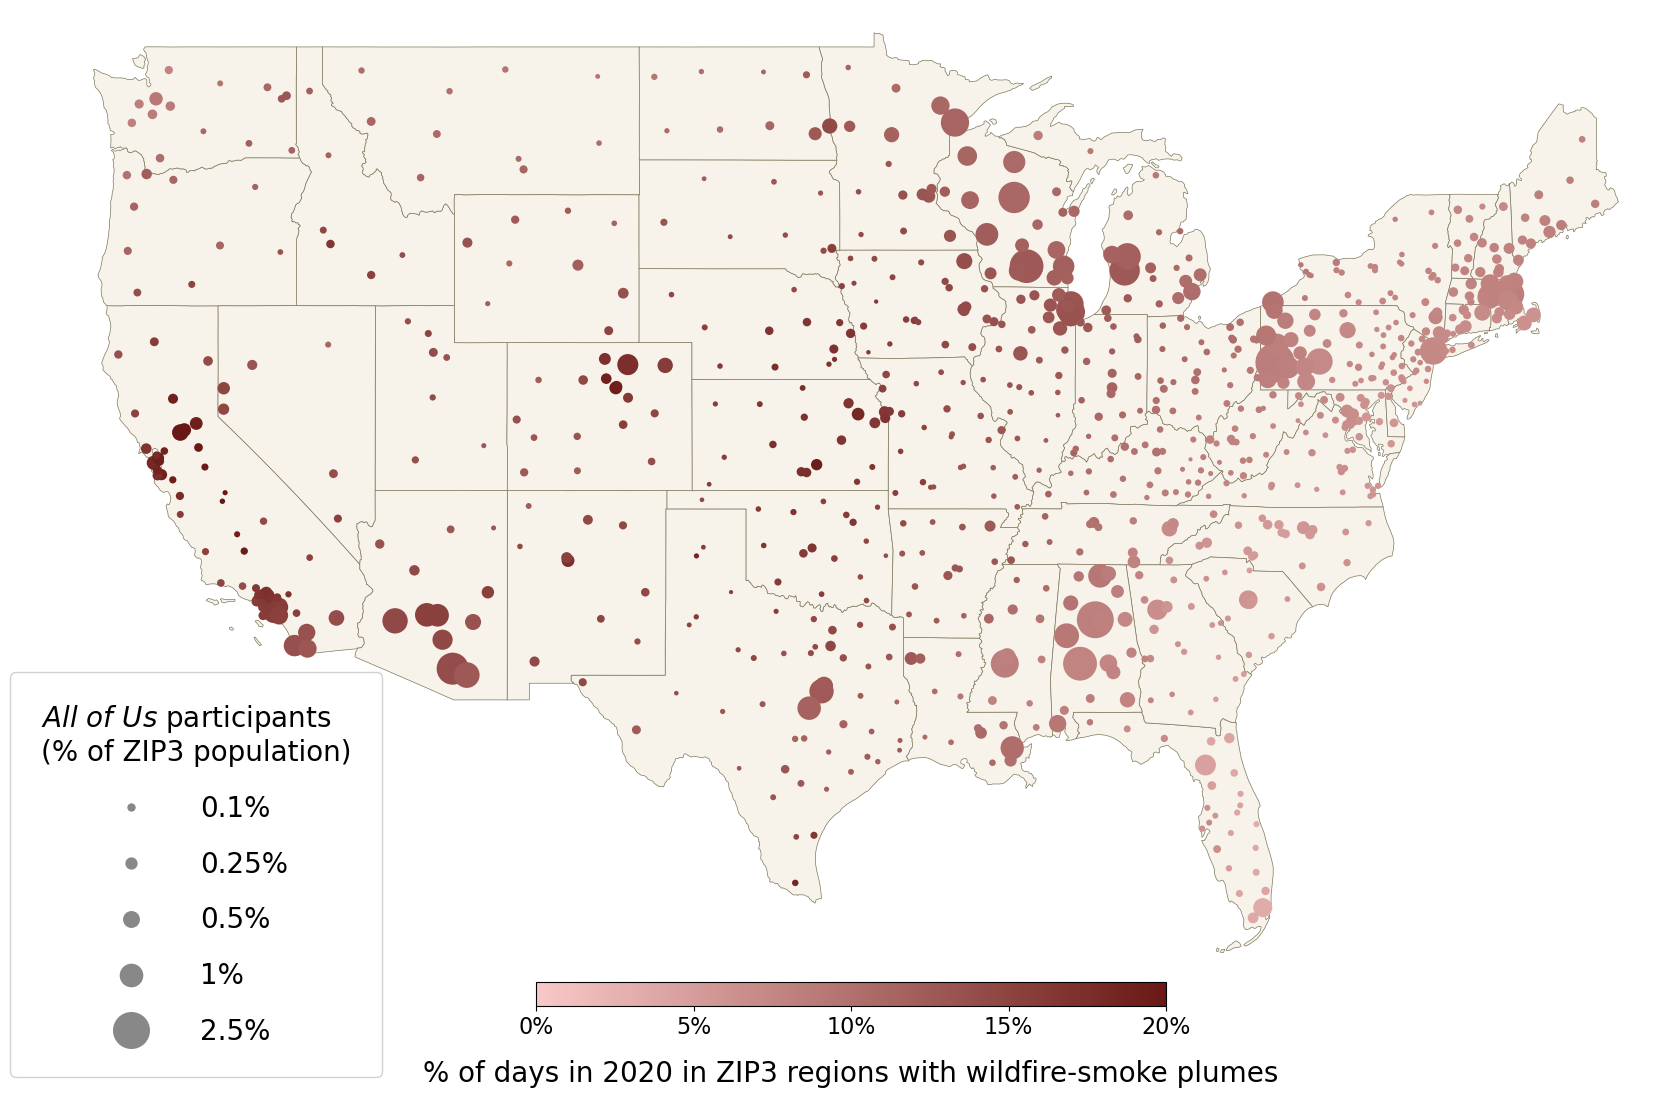

In [62]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
import numpy as np
import urllib.request, zipfile, os
import warnings
warnings.filterwarnings("ignore")
YEAR      = 2020
DAYS_YEAR = 365   # change to 366 for leap years: 2016, 2020, 2024

# ── 1. US STATES SHAPEFILE (downloads once) ───────────────────────────────────
STATES_DIR  = "us_states_shp"
STATES_PATH = f"{STATES_DIR}/cb_2020_us_state_20m.shp"
if not os.path.exists(STATES_PATH):
    url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_state_20m.zip"
    urllib.request.urlretrieve(url, "us_states.zip")
    with zipfile.ZipFile("us_states.zip") as z:
        z.extractall(STATES_DIR)
states = gpd.read_file(STATES_PATH)
conus  = states[~states["STUSPS"].isin(["AK","HI","PR","VI","GU","MP","AS"])]

# ── 2. SMOKE DATA ─────────────────────────────────────────────────────────────
smoke = pd.read_csv("zip3_year_light_med_heavy_2014_2025.csv")
smoke.columns = smoke.columns.str.strip()
smoke["zip3"] = smoke["zip3"].astype(str).str.strip().str.zfill(3)
smoke = smoke[smoke["year"] == YEAR].copy()
smoke["smoke_pct"] = (smoke["light"] + smoke["medium"] + smoke["heavy"]) / DAYS_YEAR * 100

# ── 3. PARTICIPANT PROPORTIONS ────────────────────────────────────────────────
participants_df = pd.read_csv("dataset_zip3.prop_percent.csv", dtype={"zip3": str})
participants_df["zip3"] = participants_df["zip3"].str.zfill(3)
participants_df = participants_df[["zip3", "n_individuals", "prop_percent"]]

# ── 4. CENTROIDS FROM GEOJSON ─────────────────────────────────────────────────
gdf = gpd.read_file("zip3_shapes.geojson")
gdf["zip3"] = gdf["zip3"].astype(str).str.strip().str.zfill(3)
gdf_proj = gdf.to_crs("ESRI:102003")
gdf["centroid"] = gdf_proj.geometry.centroid
gdf["lon"] = gdf.set_geometry("centroid").to_crs("EPSG:4326").geometry.x
gdf["lat"] = gdf.set_geometry("centroid").to_crs("EPSG:4326").geometry.y
centroids = gdf[["zip3","lon","lat"]].copy()

# ── 5. MERGE ──────────────────────────────────────────────────────────────────
df = smoke.merge(participants_df, on="zip3", how="inner")
df = df.merge(centroids, on="zip3", how="inner")
df = df.rename(columns={"prop_percent": "n_participants"})

# ── 6. RESTRICT TO CONUS ZIP3s ────────────────────────────────────────────────
def region(z):
    n = int(z)
    if 995 <= n <= 999: return "AK"
    if 967 <= n <= 968: return "HI"
    if 6   <= n <= 9:   return "PR"
    return "CONUS"
df["region"] = df["zip3"].apply(region)
df = df[df["region"] == "CONUS"].copy()
#print(f"Min prop_percent (CONUS): {df['n_participants'].min():.4f}%")
#print(f"Max prop_percent (CONUS): {df['n_participants'].max():.4f}%")
#print(f"Number of ZIP3s below 0.01%: {(df['n_participants'] < 0.01).sum()}")
#print(f"Number of ZIP3s below 0.05%: {(df['n_participants'] < 0.05).sum()}")

# ── 7. BUBBLE COLOR: smoke % via YlOrBr colormap ─────────────────────────────
#CMAP = cm.get_cmap("YlOrBr")
CMAP = mcolors.LinearSegmentedColormap.from_list("custom_red", ["#F9C9C7", "#691815"])
#CMAP = mcolors.LinearSegmentedColormap.from_list("custom_grey", ["#E3E2EA", "#212C3E"])
VMIN = 0
VMAX = df["smoke_pct"].quantile(0.98)
norm = mcolors.Normalize(vmin=0, vmax=20)
#norm = mcolors.Normalize(vmin=VMIN, vmax=VMAX)
df["color"] = df["smoke_pct"].apply(lambda p: "#d1d1d1" if p == 0 else mcolors.to_hex(CMAP(norm(p))))

# ── 8. BUBBLE SIZE: proportion of local population ────────────────────────────
max_p = df["n_participants"].max()
MIN_S, MAX_S = 8, 800
def bubble_size(n):
    return MIN_S + (n / max_p) * (MAX_S - MIN_S)
df["size"] = df["n_participants"].apply(bubble_size)

# ── 9. FIGURE ─────────────────────────────────────────────────────────────────
BG     = "white"
LAND   = "#F7F3EB"
BORDER = "#7D785B"
fig = plt.figure(figsize=(18, 12), facecolor=BG)
ax = fig.add_axes([0.2, 0.10, 0.88, 0.82])
ax.set_facecolor(BG)
conus.plot(ax=ax, color=LAND, edgecolor=BORDER, linewidth=0.5)
df_plot = df.sort_values("n_participants", ascending=False)
ax.scatter(df_plot["lon"], df_plot["lat"],s=df_plot["size"], c=df_plot["color"], edgecolors="none", zorder=3)
ax.set_xlim(-125, -65)
ax.set_ylim(24, 50)
ax.set_aspect(1.4)
ax.set_anchor("W")  # lock map to left side, prevents drift
ax.set_xticks([]); ax.set_yticks([])
for sp in ax.spines.values(): sp.set_visible(False)
#ax.set_title(f"Wildfire Smoke Exposure by ZIP3 for Year {YEAR}",fontsize=18, fontweight="bold", pad=10)

# ── 10. BUBBLE SIZE LEGEND (lower left) ───────────────────────────────────────
size_vals = [0.10, 0.25, 0.50, 1.0, 2.5]
size_handles = [
    mlines.Line2D([], [], marker="o", color="none",markerfacecolor="#888888", markeredgecolor="none",
                  markersize=np.sqrt(bubble_size(v)),label=f"{v:.2g}%")
    for v in size_vals]
fig.legend(
    handles=size_handles,
    title="$\\it{All\\ of\\ Us}$ participants\n(% of ZIP3 population)",
    loc="lower left",
    bbox_to_anchor=(0.15, 0.01),
    ncol=1, fontsize=20, title_fontsize=20,
    frameon=True, framealpha=0.9, edgecolor="#cccccc",
    handletextpad=1.5, labelspacing=1.0, borderpad=1.1,)

# ── 11. COLORBAR (lower right of center) ──────────────────────────────────────
cbar_ax = fig.add_axes([0.45, 0.08, 0.35, 0.02])
cb = ColorbarBase(cbar_ax, cmap=CMAP, norm=norm, orientation="horizontal")
cb.set_label("% of days in 2020 in ZIP3 regions with wildfire-smoke plumes", fontsize=20, labelpad=15, loc="center")
cb.set_ticks([0, 5, 10, 15, 20])
cb.ax.tick_params(labelsize=16)
cb.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── 12. SAVE ──────────────────────────────────────────────────────────────────
plt.savefig(f"smoke_bubble_map_{YEAR}_062926.png", dpi=200, bbox_inches="tight", facecolor=BG)
plt.show()

In [2]:
wb resource list

SyntaxError: invalid syntax (3812238710.py, line 1)